In [15]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os

df = pd.read_csv('data.csv')
df.head(5)
df.describe()
df.info()
nulos = df.isnull().sum()
porcentagem_nulos = (nulos / len(df)) * 100
print(
    f'\nNúmero de valores nulos por coluna:\n {nulos[nulos > 0]}'
    f'Porcentagem de valores nulos por coluna:\n {porcentagem_nulos[porcentagem_nulos > 0]}'
)


duplicadas = df.duplicated().sum()
print(f'Número de filas duplicadas: {duplicadas}')

idades_minimas = df['person_age'].min()
idades_maximas = df['person_age'].max()
print(f'Idade mínima: {idades_minimas}')
print(f'Idade máxima: {idades_maximas}')

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 32581 entries, 0 to 32580
Data columns (total 12 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   person_age                  32581 non-null  int64  
 1   person_income               32581 non-null  int64  
 2   person_home_ownership       32581 non-null  object 
 3   person_emp_length           31686 non-null  float64
 4   loan_intent                 32581 non-null  object 
 5   loan_grade                  32581 non-null  object 
 6   loan_amnt                   32581 non-null  int64  
 7   loan_int_rate               29465 non-null  float64
 8   loan_status                 32581 non-null  int64  
 9   loan_percent_income         32581 non-null  float64
 10  cb_person_default_on_file   32581 non-null  object 
 11  cb_person_cred_hist_length  32581 non-null  int64  
dtypes: float64(3), int64(5), object(4)
memory usage: 3.0+ MB

Número de valores nulos por co

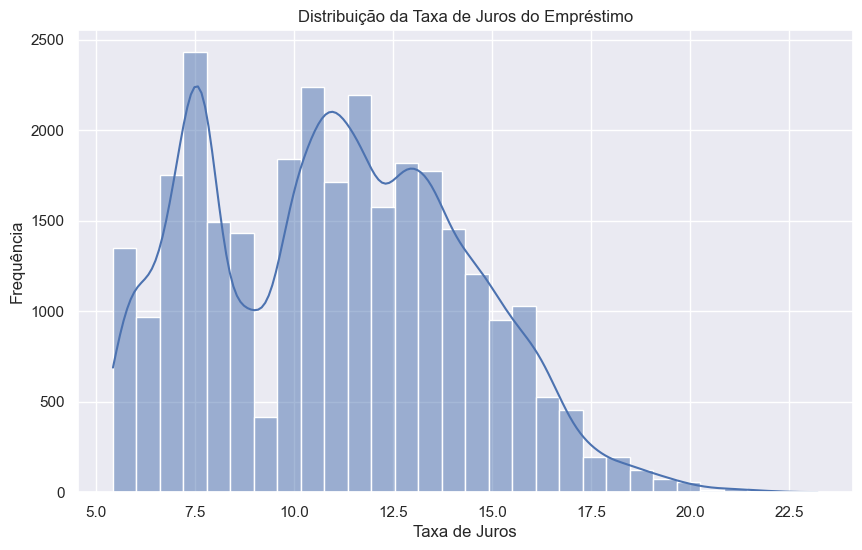

In [16]:
# como as duplicatas representam uma pequena porcentagem do total de registros e que é muito improvável que pessoas diferentes tenham exatamente os mesmos dados, vamos remover as duplicatas

df_tratado = df.drop_duplicates()

# antes de finalizar a limpeza, é interessante plotar alguns gráficos para buscar mais evidencias para justificar a substituição por media ou mediana no tratamento dos nulos.

#"Escolhi loan_int_rate porque é uma variável com aproximadamente 10% de valores ausentes.
#  Analisar sua distribuição ajudará a decidir a técnica mais adequada para imputação dos nulos (média ou mediana).
#  Além disso, trata-se de uma variável de interesse para análises posteriores,
#  como verificar se clientes inadimplentes tendem a receber empréstimos com taxas de juros diferentes."

sns.set_theme(style="darkgrid")

plt.figure(figsize=(10, 6))

sns.histplot(data=df_tratado, x='loan_int_rate', bins=30, kde=True)
plt.title('Distribuição da Taxa de Juros do Empréstimo')
plt.xlabel('Taxa de Juros')
plt.ylabel('Frequência')
plt.show()